In [217]:
!pip3 install matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import torch
import numpy as np
from random import randint
import torch.nn.functional as F


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [218]:
# Читаем все фильмы
items = pd.read_csv('/Users/user/Downloads/recsys_course/items.csv')

In [219]:
items.head(4)

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."


In [220]:
# Пользуемся ohe для кодировки кат фичей
items_ohe = items.item_id
cat_features_items = ['content_type', 'release_year',
                  'for_kids', 'age_rating',
                  'studios', 'countries', 'directors']

for feature in cat_features_items:
  ohe_df = pd.get_dummies(items[feature])
  items_ohe = pd.concat([items_ohe, ohe_df], axis=1)
items_ohe.head()

,item_id,film,series,1897.0,1916.0,1917.0,1918.0,1920.0,1921.0,1922.0,...,Яннике Систад Якобсен,Янус Мец,Ярив Хоровиц,Ярон Зильберман,Ярополк Лапшин,Ярослав Лупий,"Ярроу Чейни, Скотт Моужер",Ясина Сезар,Ясуоми Умэцу,сения Завьялова
0,10711,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2508,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,10716,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,7868,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,16268,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [221]:
# Тут читаем всех юзеров вместе с их фичами
users = pd.read_csv('/Users/user/Downloads/recsys_course/users.csv')

In [222]:
users.head(4)

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0


In [223]:
users_ohe = users.user_id
cat_features_users = users.select_dtypes(include=['object']).columns.tolist()
for feature in cat_features_users:
  ohe_df = pd.get_dummies(users[feature])
  users_ohe = pd.concat([users_ohe, ohe_df], axis=1)
users_ohe.head()

,user_id,age_18_24,age_25_34,age_35_44,age_45_54,age_55_64,age_65_inf,income_0_20,income_150_inf,income_20_40,income_40_60,income_60_90,income_90_150,Ж,М
0,973171,False,True,False,False,False,False,False,False,False,False,True,False,False,True
1,962099,True,False,False,False,False,False,False,False,True,False,False,False,False,True
2,1047345,False,False,False,True,False,False,False,False,False,True,False,False,True,False
3,721985,False,False,False,True,False,False,False,False,True,False,False,False,True,False
4,704055,False,False,True,False,False,False,False,False,False,False,True,False,True,False


In [224]:
# Читаем взаимодействия между пользователем и товаром
interactions = pd.read_csv('/Users/user/Downloads/recsys_course/interactions.csv')

In [225]:
interactions.head(4)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0


In [226]:
# Фильтруем взаимодействия с фильмами (чтобы избежать просмотра фильма, который не понравился
# можно было бы воспользоваться данной информации как генератор для негативных сэмплов, мб дальше так и сделаю)
interactions = interactions[interactions['watched_pct'] >= 5]

In [227]:
# Фильтруем холодные фильмы (фозможность в модельке работы с холодным пользователем есть,а вот если и пользователь холодный
# и фильм холодный, то ужас)
mask = interactions.groupby('item_id')['item_id'].transform('size') >= 10
interactions = interactions[mask]

In [228]:
interactions['last_watch_dt'] = pd.to_datetime(interactions['last_watch_dt'])
max_date = interactions['last_watch_dt'].max()

In [229]:
# Тут решаем удалить тех пользователей которых нет в interactions и наоборот, удаляем вроде как холодных пользователей,
# но для модельки мы будем просто иногда занулять историю просмотра (попробуем без зануления и посмотрим на метрики)
common_users = set(interactions.user_id.unique()).intersection(set(users_ohe.user_id.unique()))
common_items = set(interactions.item_id.unique()).intersection(set(items_ohe.item_id.unique()))

In [230]:
# Тут решаем добавить уникальный айдишник и еще сделать матрицу взаимодействий,
# i-му пользователю сопоставлен вектор из истории просмотров товаров по их уник индексам
interactions = interactions[interactions.user_id.isin(common_users)]
interactions = interactions[interactions.item_id.isin(common_items)]

users_ohe = users_ohe[users_ohe.user_id.isin(common_users)]
items_ohe = items_ohe[items_ohe.item_id.isin(common_items)]

interactions["uid"] = interactions["user_id"].astype("category")
interactions["uid"] = interactions["uid"].cat.codes

interactions["iid"] = interactions["item_id"].astype("category")
interactions["iid"] = interactions["iid"].cat.codes

interactions_vec = np.zeros((interactions.uid.nunique(),
                             interactions.iid.nunique()))

for user_id, item_id in zip(interactions.uid, interactions.iid):
    interactions_vec[user_id, item_id] += 1


In [231]:
res = interactions_vec.sum(axis=1)
for i in range(len(interactions_vec)):
    interactions_vec[i] /= res[i]

In [232]:
# Для удобства сделаем словарики чтобы было удобно конвертировать из item в iid и с user тож самое
iid_to_item = interactions[["iid", "item_id"]].drop_duplicates().set_index("iid").to_dict()["item_id"]
item_to_iid = interactions[["iid", "item_id"]].drop_duplicates().set_index("item_id").to_dict()["iid"]

uid_to_user = interactions[["uid", "user_id"]].drop_duplicates().set_index("uid").to_dict()["user_id"]
user_to_uid = interactions[["uid", "user_id"]].drop_duplicates().set_index("user_id").to_dict()["uid"]

Обучение модели


In [233]:
from torch import nn
import os
from sklearn.metrics.pairwise import euclidean_distances as ED

In [234]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cpu device


In [266]:
# Для начала поймем какой loss будем использовать, я выбрал triplesloss

def triplet_loss(y_pred, n_dims=128, alpha=0.25):
    
 # Разделяем y_pred на anchor, positive и negative
    anchor = y_pred[:, 0:n_dims]  # (batch_size, n_dims)
    positive = y_pred[:, n_dims:n_dims * 2]  # (batch_size, n_dims)
    negative = y_pred[:, n_dims * 2:n_dims * 3]  # (batch_size, n_dims)

    # Вычисляем расстояния для каждого элемента батча
    positive_dist = torch.norm(anchor - positive, p=2, dim=1)  # (batch_size,)
    negative_dist = torch.norm(anchor - negative, p=2, dim=1)  # (batch_size,)

    # Вычисляем Triplet Loss
    losses = torch.relu(positive_dist - negative_dist + alpha)  # (batch_size,)

    # Усредняем по батчу
    return losses.mean()

In [267]:
# Разберемся теперь с сэмплированием негативных и позитивных примеров

def generator(users=users_ohe,
              items=items_ohe,
              interactions_vec=interactions_vec,
              uid_to_user=uid_to_user,
              iid_to_item=iid_to_item,
              batch_size=512):
    num_users = interactions_vec.shape[0]
    num_items = interactions_vec.shape[1]
    
    while True:
        users_batch = []
        interactions_batch = []
        positive_items = []
        negative_items = []

        for _ in range(batch_size):
            uid_i = randint(0, num_users - 1)
            pos_i = np.random.choice(range(num_items), p=interactions_vec[uid_i])
            neg_i = randint(0, num_items - 1)
            while neg_i == pos_i:
                neg_i = randint(0, num_items - 1)
            
            interactions_batch.append(interactions_vec[uid_i])
            users_batch.append(users[users["user_id"] == uid_to_user[uid_i]].iloc[:, 1:].values)
            positive_items.append(items[items["item_id"] == iid_to_item[pos_i]].iloc[:, 1:].values)
            negative_items.append(items[items["item_id"] == iid_to_item[neg_i]].iloc[:, 1:].values)

        users_batch = torch.tensor(np.array(users_batch), dtype=torch.float32).squeeze()
        interactions_batch = torch.tensor(np.array(interactions_batch), dtype=torch.float32)
        positive_items = torch.tensor(np.array(positive_items), dtype=torch.float32).squeeze()
        negative_items = torch.tensor(np.array(negative_items), dtype=torch.float32).squeeze()

        yield users_batch, interactions_batch, positive_items, negative_items

In [268]:
OUTPUT_DIM = 128

ITEM_FEATURE_SHAPE = (items_ohe.drop(["item_id"], axis=1).shape[1])
USER_META_SHAPE = (users_ohe.drop(["user_id"], axis=1).shape[1])
USER_INTERACTION_MODEL_SHAPE = (interactions_vec.shape[1])

In [280]:
class RecModel(nn.Module):
    def __init__(self, n_factors=OUTPUT_DIM,
                 item_dim=ITEM_FEATURE_SHAPE, user_dim=USER_META_SHAPE,
                 interactions_dim=USER_INTERACTION_MODEL_SHAPE, users=users_ohe, 
                 items=items_ohe, interactions_vec=interactions_vec,
                 interactions=interactions, uid_to_user=uid_to_user, 
                 iid_to_item=iid_to_item):
        super().__init__()
        
        # Сохраняем данные
        self.items = items
        self.users = users
        self.interactions_vec = interactions_vec
        self.interactions = interactions
        self.uid_to_user = uid_to_user
        self.iid_to_item = iid_to_item
        
        # Слои для пользователя и истории просмотров
        self.user_fc1_meta = nn.Linear(user_dim, n_factors, bias=False)
        self.user_fc1_interaction = nn.Linear(interactions_dim, n_factors, bias=False)
        self.user_fc2_meta = nn.Linear(n_factors, n_factors, bias=False)
        self.user_fc3 = nn.Linear(n_factors * 2, n_factors, bias=False)

        # Слои для айтема
        self.item_fc1 = nn.Linear(item_dim, n_factors, bias=False)
        self.item_fc2 = nn.Linear(n_factors, n_factors, bias=False)
        self.item_fc3 = nn.Linear(n_factors, n_factors, bias=False)

    def forward_user(self, user_meta, interaction_meta):
        """Вычисляет эмбеддинг пользователя."""
        layer_1_meta = F.elu(self.user_fc1_meta(user_meta))
        layer_1_interaction = F.elu(self.user_fc1_interaction(interaction_meta))

        layer_2_meta = F.elu(self.user_fc2_meta(layer_1_meta))

        # Residual connection
        add = layer_1_meta + layer_2_meta

        # Конкатенация
        concat_meta_interaction = torch.cat([add, layer_1_interaction], dim=1)

        user_out = self.user_fc3(concat_meta_interaction)
        return user_out

    def forward_item(self, x):
        """Вычисляет эмбеддинг айтема."""
        layer_1 = F.elu(self.item_fc1(x))
        layer_2 = F.elu(self.item_fc2(layer_1))

        # Residual connection
        add = layer_1 + layer_2

        item_out = self.item_fc3(add)
        return item_out

    def forward(self, ancor_meta, ancor_interaction, pos, neg):
        """Прямой проход для обучения."""
        # Получаем вектор пользователя
        ancor = self.forward_user(ancor_meta, ancor_interaction)

        # Получаем векторы айтемов
        pos = self.forward_item(pos)
        neg = self.forward_item(neg)

        # Конкатенация для вывода
        res = torch.cat([ancor, pos, neg], dim=1)
        return res

    def predict(self, ancor_meta, ancor_interaction, item_meta):
        """Предсказывает расстояние между пользователем и айтемом."""
        ancor = self.forward_user(ancor_meta, ancor_interaction)
        item_embedding = self.forward_item(item_meta)

        # Вычисляем евклидово расстояние
        return torch.norm(ancor - item_embedding, p=2).item()

    def top_rec(self, uid, k=10):
        """Возвращает топ-K рекомендаций для пользователя."""
        top_k = {}
        
        # Получаем метаданные пользователя
        user_meta = torch.tensor(
            self.users[self.users["user_id"] == self.uid_to_user[uid]].iloc[:, 1:].values,
            dtype=torch.float32
        )
        
        # Получаем взаимодействия пользователя
        interactions_meta = torch.tensor(
            self.interactions_vec[uid],
            dtype=torch.float32
        ).unsqueeze(0)
        
        # Проходим по всем айтемам
        for iid in range(self.items.shape[0]):
            # Получаем метаданные айтема
            item_meta = torch.tensor(
                self.items[self.items["item_id"] == self.iid_to_item[iid]].iloc[:, 1:].values,
                dtype=torch.float32
            )
            
            # Вычисляем расстояние
            distance = self.predict(user_meta, interactions_meta, item_meta)
            top_k[iid] = list(distance)
        
        return sorted(top_k.items(), key=lambda item: item[1])[:k]

Epoch 1, Loss: 0.250128835439682
Epoch 2, Loss: 0.24219878017902374
Epoch 3, Loss: 0.2279878705739975
Epoch 4, Loss: 0.2062055766582489
Epoch 5, Loss: 0.17624008655548096
Epoch 6, Loss: 0.16669660806655884
Epoch 7, Loss: 0.13804693520069122
Epoch 8, Loss: 0.13898241519927979
Epoch 9, Loss: 0.1331818401813507
Epoch 10, Loss: 0.11839818954467773
Epoch 11, Loss: 0.11617855727672577
Epoch 12, Loss: 0.108793243765831
Epoch 13, Loss: 0.11968866735696793
Epoch 14, Loss: 0.09908228367567062
Epoch 15, Loss: 0.10118696093559265
Epoch 16, Loss: 0.09135769307613373
Epoch 17, Loss: 0.08722605556249619
Epoch 18, Loss: 0.10429836064577103
Epoch 19, Loss: 0.08693388104438782
Epoch 20, Loss: 0.08439803123474121
Epoch 21, Loss: 0.07200354337692261
Epoch 22, Loss: 0.0802198052406311
Epoch 23, Loss: 0.07814912497997284
Epoch 24, Loss: 0.08773693442344666
Epoch 25, Loss: 0.09077288210391998
Epoch 26, Loss: 0.0880899429321289
Epoch 27, Loss: 0.06521566212177277
Epoch 28, Loss: 0.07815509289503098
Epoch 29, 

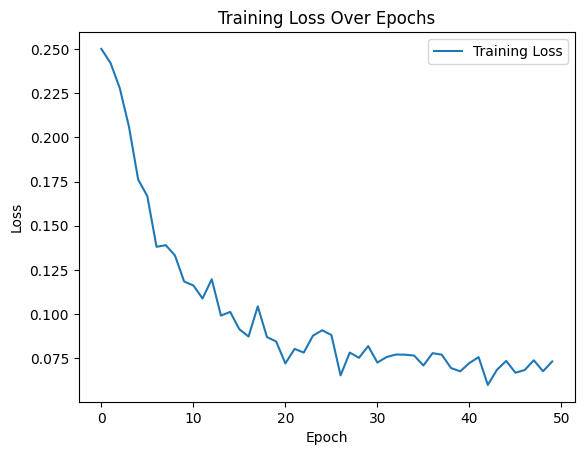

In [281]:

# Основной процесс обучения
def train_model(users_meta, items_meta, interactions_vec, uid_to_user, iid_to_item, epochs=50, batch_size=512, learning_rate=0.001):
    # Инициализация модели и оптимизатора
    model = RecModel()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Создание генератора данных
    gen = generator()

    # Логирование потерь
    losses = []

    # Цикл обучения
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        # Получаем батч данных
        users_batch, interactions_batch, positive_items, negative_items = next(gen)

        # Перемещаем данные на устройство
        users_batch = users_batch.to(device)
        interactions_batch = interactions_batch.to(device)
        positive_items = positive_items.to(device)
        negative_items = negative_items.to(device)

        # Forward pass
        out = model(users_batch, interactions_batch, positive_items, negative_items)

        # Вычисление потерь
        loss = triplet_loss(out)

        # Backward pass и оптимизация
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Суммируем потери за эпоху
        epoch_loss += loss.item()
        losses.append(epoch_loss)

        print(f"Epoch {epoch + 1}, Loss: {epoch_loss}")

    # Визуализация потерь
    plt.plot(losses, label="Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Over Epochs")
    plt.legend()
    plt.show()


# Запуск обучения
train_model(users_ohe, items_ohe, interactions_vec, uid_to_user, iid_to_item, epochs=50, batch_size=128)

In [308]:
def calculate_map(k=10, n=users_ohe.shape[0]):
    map10k = 0.0
    num_users_with_relevant = 0  # Количество пользователей с релевантными рекомендациями

    for uid in range(0, n):
        # Получаем топ-K рекомендаций для пользователя
        res = model.top_rec(uid, k=k)
        rec_interactions = pd.DataFrame(res, columns=["iid", "score"])

        # Добавляем колонку uid
        rec_interactions["uid"] = uid
        
        # Добавляем колонку rank (топ-1, топ-2 и т.д.)
        rec_interactions["rank"] = range(1, len(rec_interactions) + 1)
        
        # Переупорядочиваем колонки
        rec_interactions = rec_interactions[["uid", "iid", "score", "rank"]]

        # Соединяем с реальными взаимодействиями
        merged = rec_interactions.merge(interactions, on=["uid", "iid"], how="left", indicator=True)
        
        # Добавляем колонку с 1 или 0
        merged["exists"] = (merged["_merge"] == "both").astype(int)
        
        merged = merged[["uid", "iid", "rank", "exists"]]

        # Вычисляем AP@K для текущего пользователя
        relevant = 0
        precision_sum = 0.0

        for i, rel in enumerate(merged["exists"]):
            if rel:
                relevant += 1
                precision_sum += relevant / (i + 1)

        # Если есть релевантные рекомендации, вычисляем AP@K
        if relevant > 0:
            ap = precision_sum / min(relevant, k)
            map10k += ap

    return map10k / n

In [309]:
calculate_map(k=10,n=20)

0.1875